# nanoGPT training loss comparison

Parse the `iter N: loss X` lines from the 5 SLURM output files in `training_loss/` and compare training loss across weight initializations:

| File | Initialization |
|---|---|
| train_nanogpt-1214121.out | normal (std=0.02) |
| train_nanogpt-6935363.out | normal (std=0.005) |
| train_nanogpt-6933643.out | uniform (std=0.02) |
| train_nanogpt-1217267.out | xavier_uniform |
| train_nanogpt-6933651.out | xavier_normal |

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt

DIR = "training_loss"

RUNS = [
    ("train_nanogpt-1214121.out", "normal (std=0.02)"),
    ("train_nanogpt-6935363.out", "normal (std=0.005)"),
    ("train_nanogpt-6933643.out", "uniform (std=0.02)"),
    ("train_nanogpt-1217267.out", "xavier_uniform"),
    ("train_nanogpt-6933651.out", "xavier_normal"),
]

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

pat = re.compile(r"^iter (\d+): loss ([\d.]+)")

def load(fname):
    iters, losses = [], []
    with open(f"{DIR}/{fname}") as f:
        for line in f:
            m = pat.match(line)
            if m:
                iters.append(int(m.group(1)))
                losses.append(float(m.group(2)))
    return np.array(iters), np.array(losses)

def smooth(y, w=501):
    kernel = np.ones(w) / w
    pad = np.concatenate([np.full(w // 2, y[0]), y, np.full(w // 2, y[-1])])
    return np.convolve(pad, kernel, mode="valid")

kfmt = plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")

def style_ax(ax):
    ax.xaxis.set_major_formatter(kfmt)
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=9)

data = {}
for fname, name in RUNS:
    it, ls = load(fname)
    data[name] = (it, ls, smooth(ls))
    print(f"{name}: {len(it)} iters, final smoothed loss {smooth(ls)[-1]:.4f}")

normal (std=0.02): 192001 iters, final smoothed loss 2.8868
normal (std=0.005): 192001 iters, final smoothed loss 2.9348
uniform (std=0.02): 192001 iters, final smoothed loss 3.0156
xavier_uniform: 192001 iters, final smoothed loss 2.8888
xavier_normal: 192001 iters, final smoothed loss 3.0138


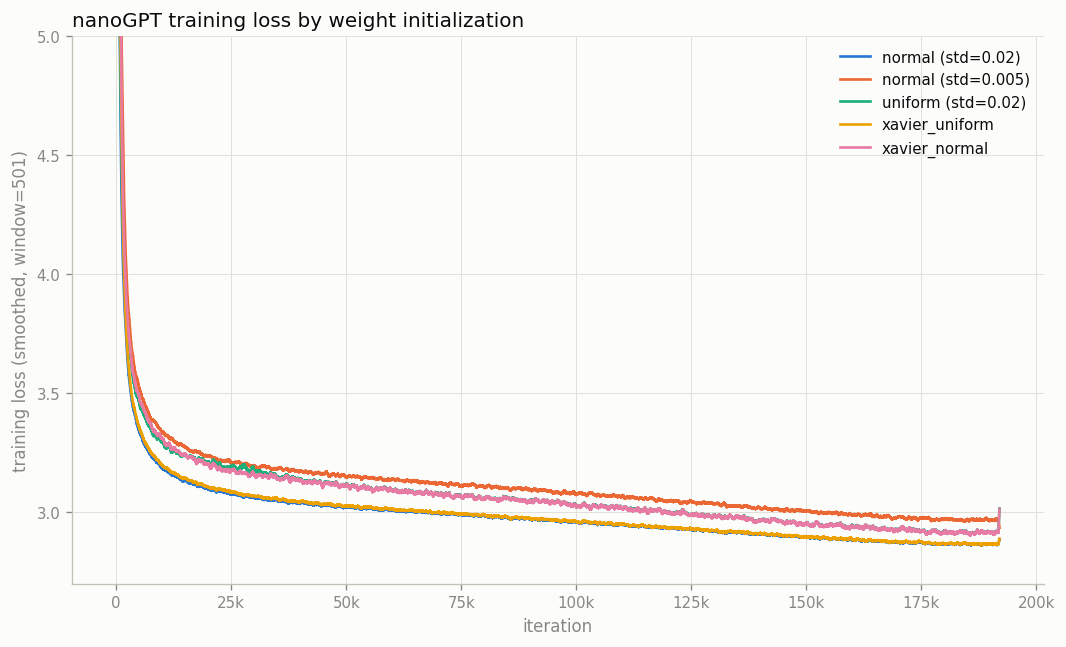

In [2]:
# Full-run comparison (smoothed). Note: normal (std=0.02) and xavier_uniform almost fully overlap
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)
fig.patch.set_facecolor(SURFACE)
style_ax(ax)
for (name, (it, ls, sm)), c in zip(data.items(), COLORS):
    ax.plot(it, sm, color=c, linewidth=1.6, label=name)
ax.set_xlabel("iteration", color=MUTED)
ax.set_ylabel("training loss (smoothed, window=501)", color=MUTED)
ax.set_title("nanoGPT training loss by weight initialization", color=INK, fontsize=12, loc="left")
ax.set_ylim(2.7, 5.0)
ax.legend(frameon=False, labelcolor=INK, fontsize=9)
fig.tight_layout()
plt.show()

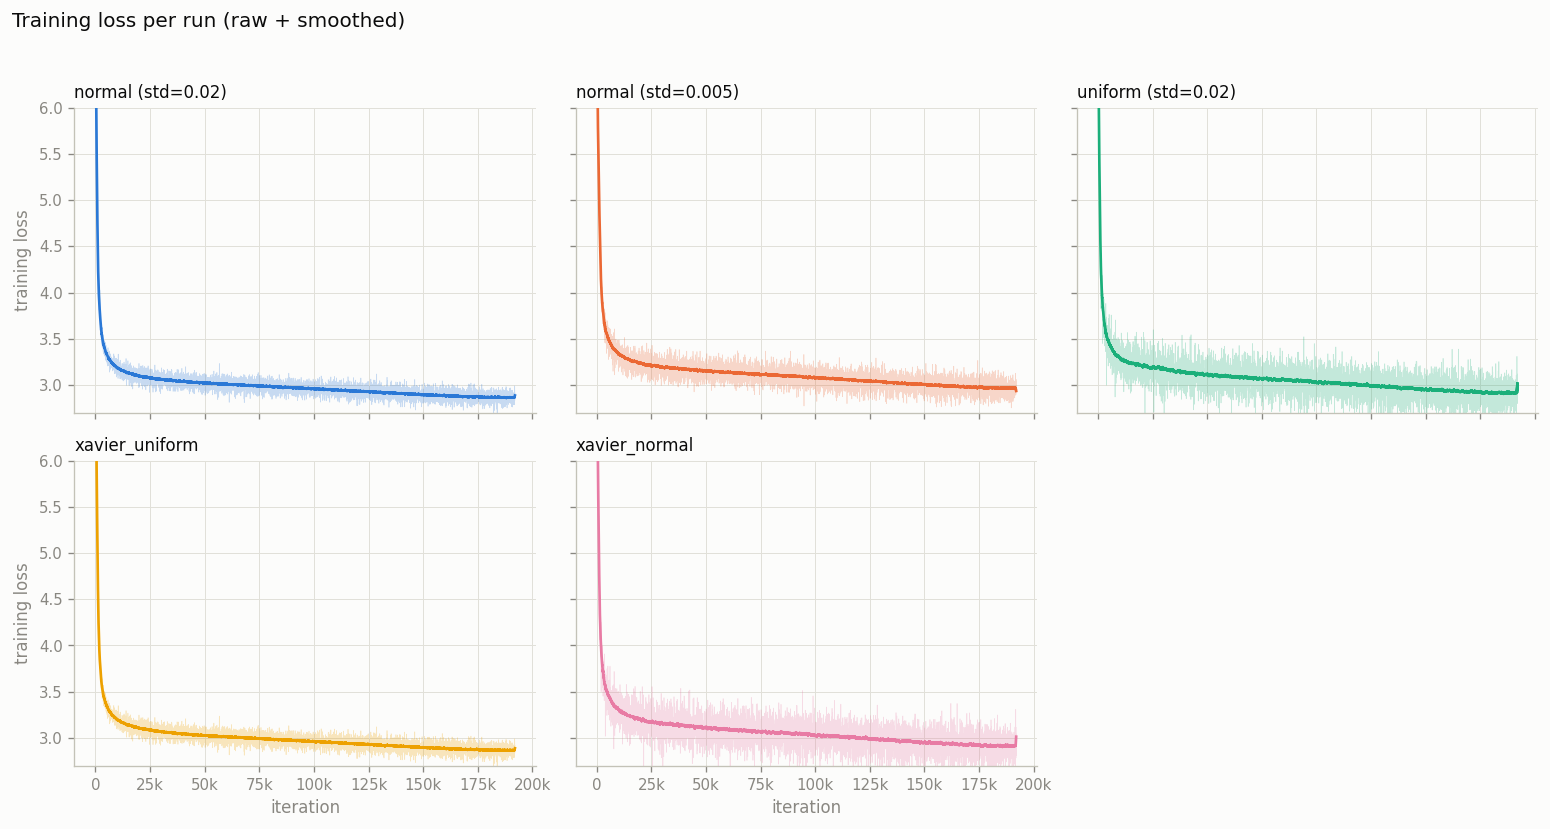

In [3]:
# One panel per run: light color = raw loss (every 20th step), solid = smoothed
fig, axes = plt.subplots(2, 3, figsize=(13, 7), dpi=120, sharex=True, sharey=True)
fig.patch.set_facecolor(SURFACE)
for axi, (name, (it, ls, sm)), c in zip(axes.flat, data.items(), COLORS):
    style_ax(axi)
    axi.plot(it[::20], ls[::20], color=c, linewidth=0.4, alpha=0.25)
    axi.plot(it, sm, color=c, linewidth=1.6)
    axi.set_title(name, color=INK, fontsize=10, loc="left")
axes.flat[-1].set_visible(False)
for axi in axes[1]:
    axi.set_xlabel("iteration", color=MUTED)
for axi in axes[:, 0]:
    axi.set_ylabel("training loss", color=MUTED)
axes[0, 0].set_ylim(2.7, 6.0)
fig.suptitle("Training loss per run (raw + smoothed)", color=INK, fontsize=12, x=0.01, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## First 1000 steps

The early descent rate differs clearly: normal/uniform (std=0.02) drop fastest; both xavier variants and normal (std=0.005) lag noticeably over the first ~100 steps, then gradually catch up.

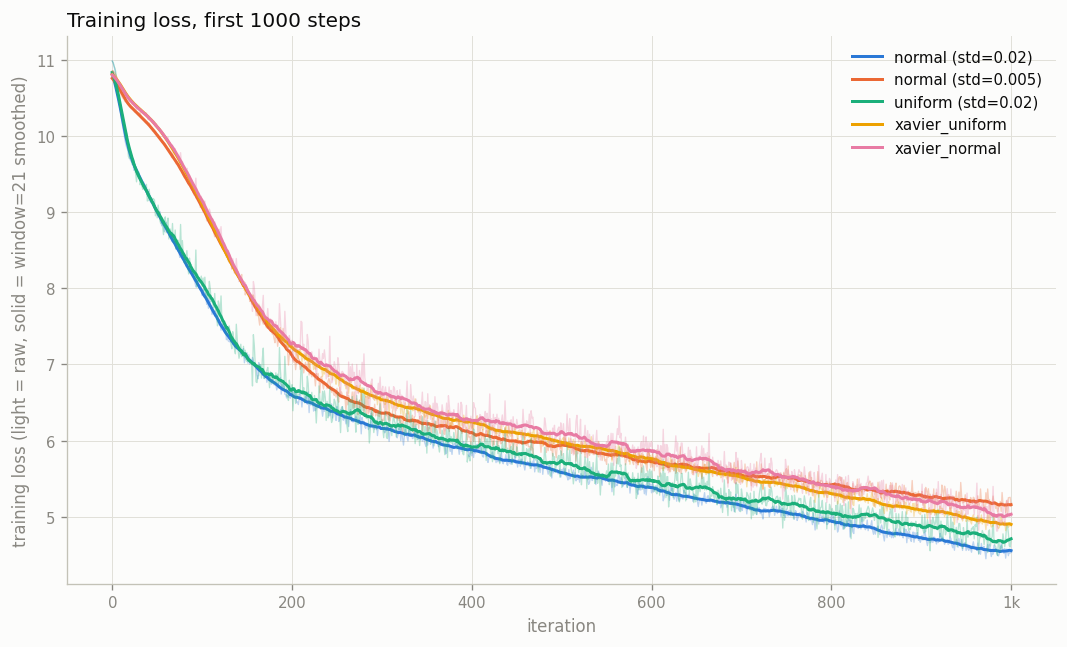

In [4]:
# Focus on the first 1000 steps: this is where initialization matters most
EARLY = 1000

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)
fig.patch.set_facecolor(SURFACE)
style_ax(ax)
for (name, (it, ls, sm)), c in zip(data.items(), COLORS):
    mask = it <= EARLY
    ax.plot(it[mask], ls[mask], color=c, linewidth=0.8, alpha=0.3)
    ax.plot(it[mask], smooth(ls[mask], w=21), color=c, linewidth=1.8, label=name)
ax.set_xlabel("iteration", color=MUTED)
ax.set_ylabel("training loss (light = raw, solid = window=21 smoothed)", color=MUTED)
ax.set_title(f"Training loss, first {EARLY} steps", color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, labelcolor=INK, fontsize=9)
fig.tight_layout()
plt.show()

## First 200 steps: the initial plateau

The gray dashed line is the uniform-prediction loss: ln(50304) ≈ 10.83 (with logits ≈ 0 the model outputs a near-uniform distribution). The three small-scale runs (both xavier variants and std=0.005, whose tied embedding/output-head matrix starts at std ≈ 0.005–0.006) start on this line and linger near it briefly; the two std=0.02 runs start higher (the logit variance adds about σ²/2 ≈ 0.15 to the loss) but show no plateau and descend immediately.

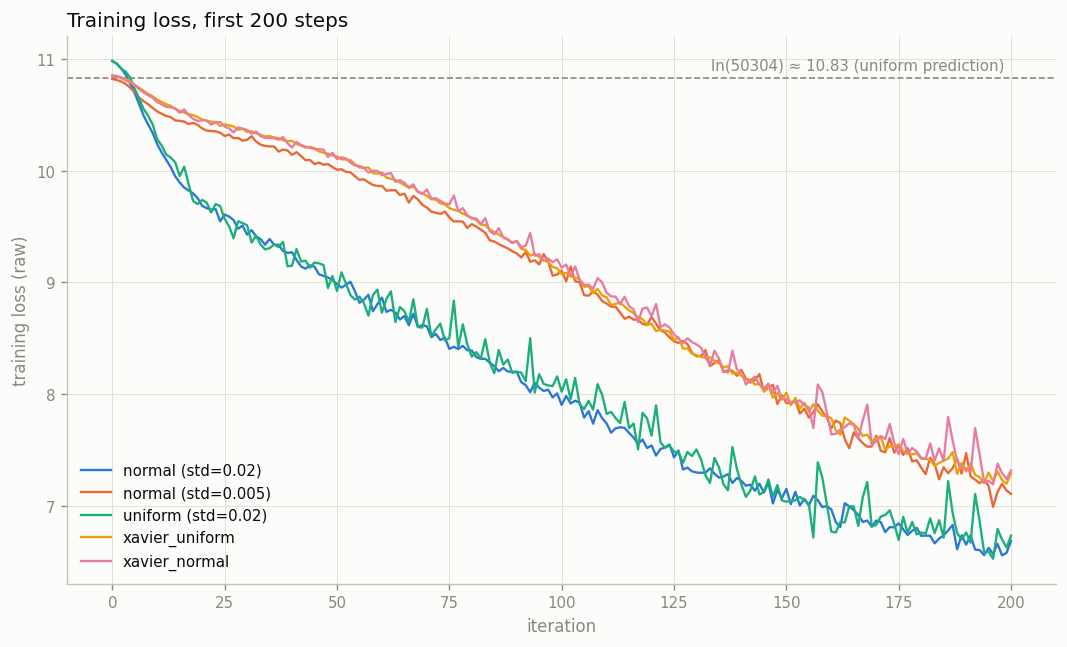

In [5]:
# First 200 steps, raw loss (no smoothing); dashed line = uniform-prediction loss ln(50304)
UNIFORM_LOSS = np.log(50304)

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=120)
fig.patch.set_facecolor(SURFACE)
style_ax(ax)
ax.axhline(UNIFORM_LOSS, color=MUTED, linewidth=1, linestyle="--")
ax.annotate(f"ln(50304) ≈ {UNIFORM_LOSS:.2f} (uniform prediction)", xy=(200, UNIFORM_LOSS),
            xytext=(-4, 5), textcoords="offset points", ha="right",
            color=MUTED, fontsize=9)
for (name, (it, ls, sm)), c in zip(data.items(), COLORS):
    mask = it <= 200
    ax.plot(it[mask], ls[mask], color=c, linewidth=1.4, label=name)
ax.set_xlabel("iteration", color=MUTED)
ax.set_ylabel("training loss (raw)", color=MUTED)
ax.set_title("Training loss, first 200 steps", color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, labelcolor=INK, fontsize=9)
fig.tight_layout()
plt.show()